<a href="https://colab.research.google.com/github/solehas25h-salmasoleha/Co-Kriging/blob/main/Co_Kriging.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

Silakan unggah file dataset (misal: meuse.csv):


<>:69: SyntaxWarning: invalid escape sequence '\l'
<>:74: SyntaxWarning: invalid escape sequence '\l'
<>:191: SyntaxWarning: invalid escape sequence '\g'
<>:69: SyntaxWarning: invalid escape sequence '\l'
<>:74: SyntaxWarning: invalid escape sequence '\l'
<>:191: SyntaxWarning: invalid escape sequence '\g'
/tmp/ipykernel_1728/18238741.py:69: SyntaxWarning: invalid escape sequence '\l'
  axes[1, 0].set_title(f'Distribusi Box-Cox - Zinc ($\lambda$ = {lam_zinc:.3f})', fontsize=11, fontweight='bold')
/tmp/ipykernel_1728/18238741.py:74: SyntaxWarning: invalid escape sequence '\l'
  axes[1, 1].set_title(f'Distribusi Box-Cox - Copper ($\lambda$ = {lam_copper:.3f})', fontsize=11, fontweight='bold')
/tmp/ipykernel_1728/18238741.py:191: SyntaxWarning: invalid escape sequence '\g'
  plt.ylabel('Semivarians $\gamma(h)$')


Saving meuse.txt to meuse (9).txt

STATISTIK DESKRIPTIF DATA AWAL:
        Count        Mean         Std    Min  Median     Max
zinc    155.0  469.716129  367.073788  113.0   326.0  1839.0
copper  155.0   40.316129   23.680436   14.0    31.0   128.0

Optimal Lambda Box-Cox Zinc   : -0.2728
Optimal Lambda Box-Cox Copper : -0.7454


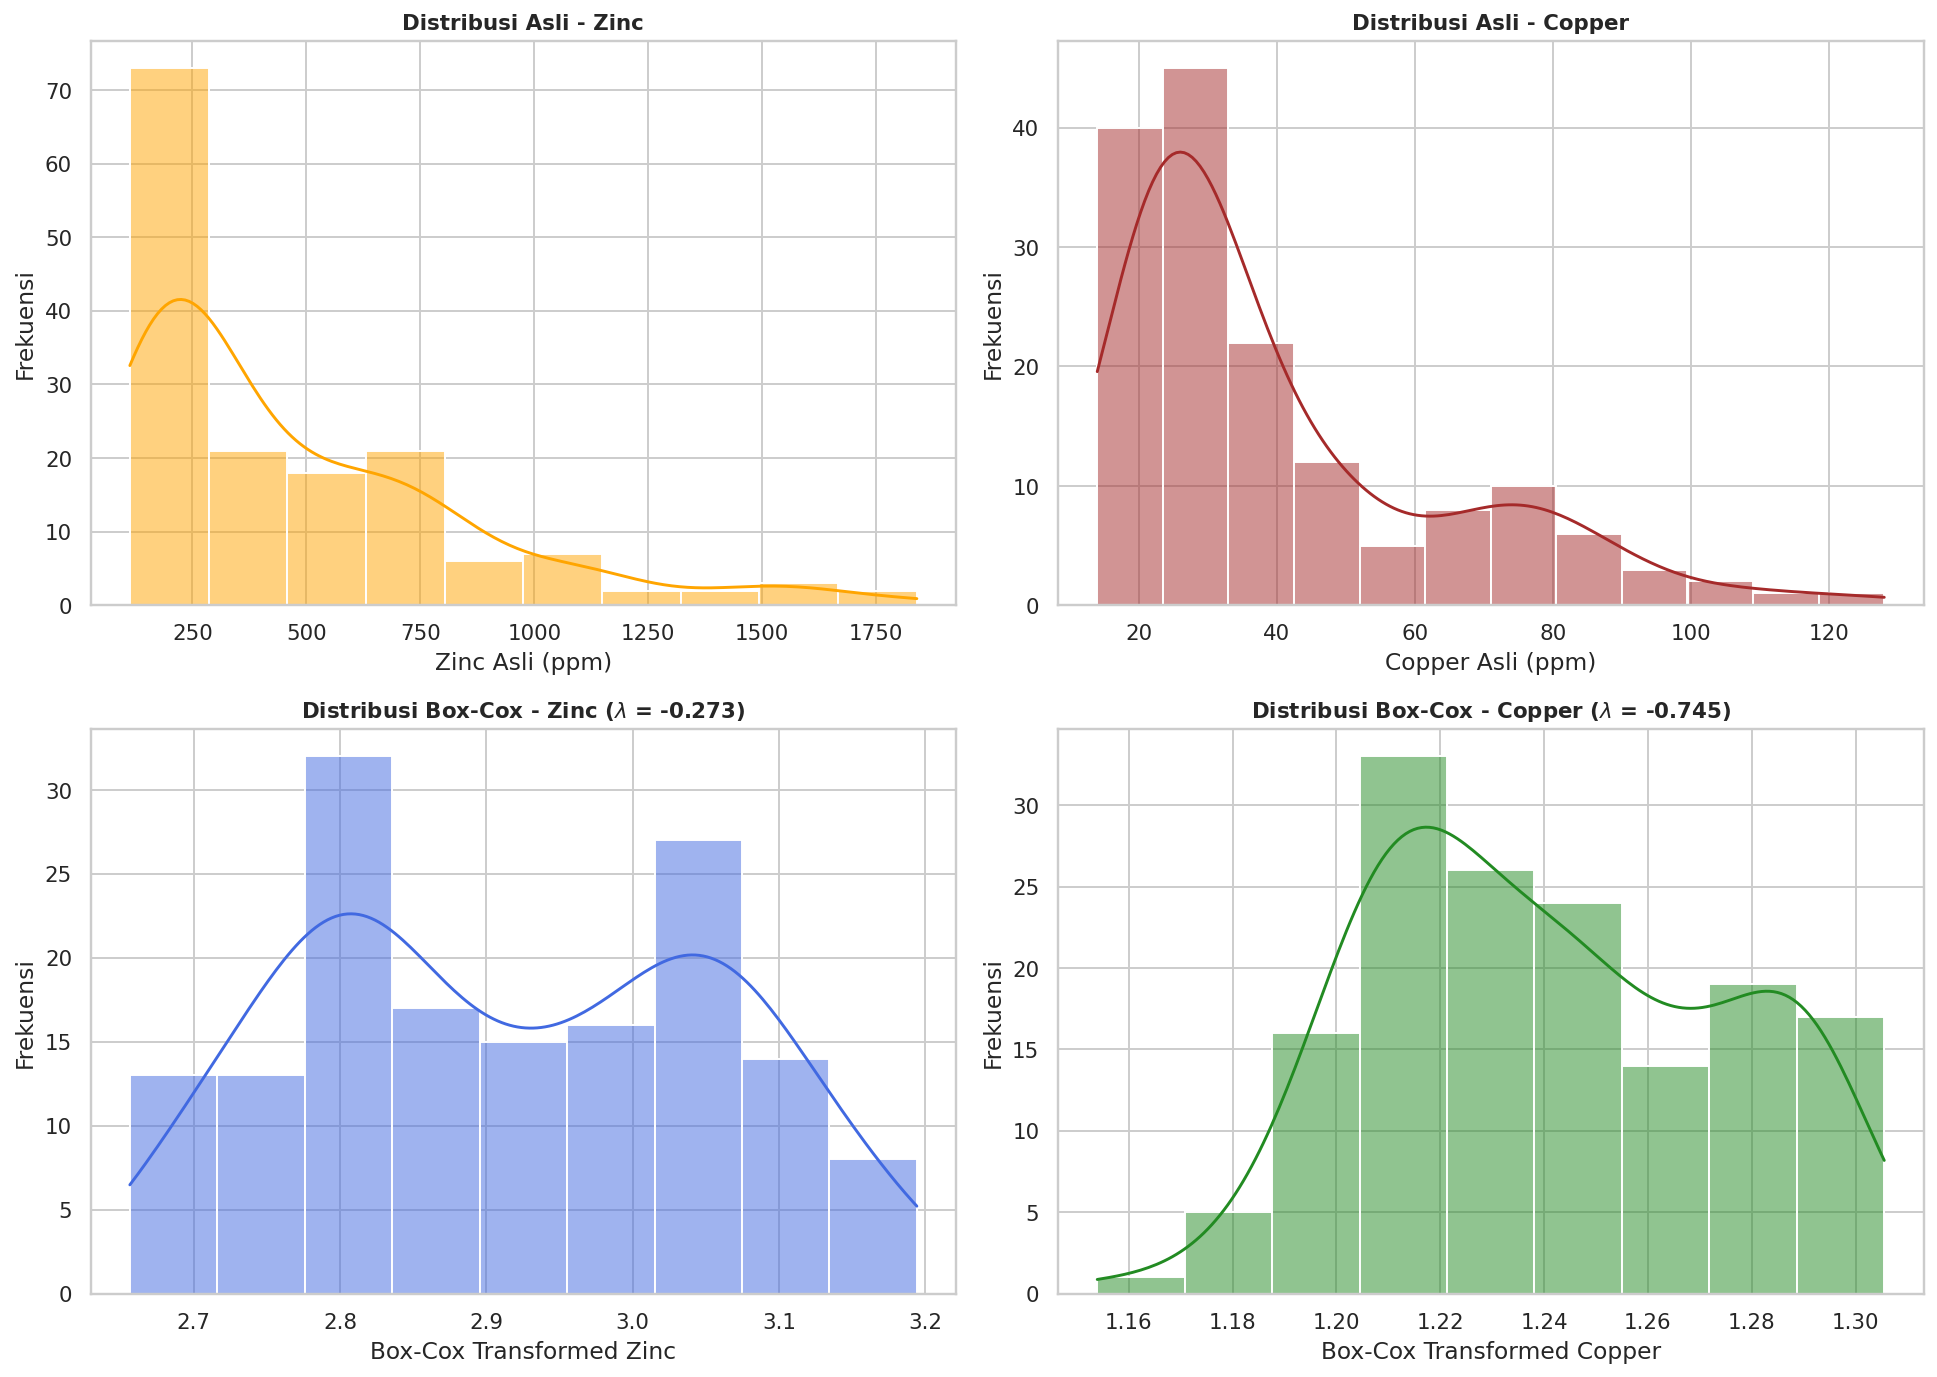


 TABEL PERBANDINGAN SSE (SUM OF SQUARED ERRORS)
 SSE Model Spherikal    : 0.0000
 SSE Model Eksponensial : 0.0001
 SSE Model Gaussian     : 0.0001
 Model Variogram Terbaik Terpilih : Spherical


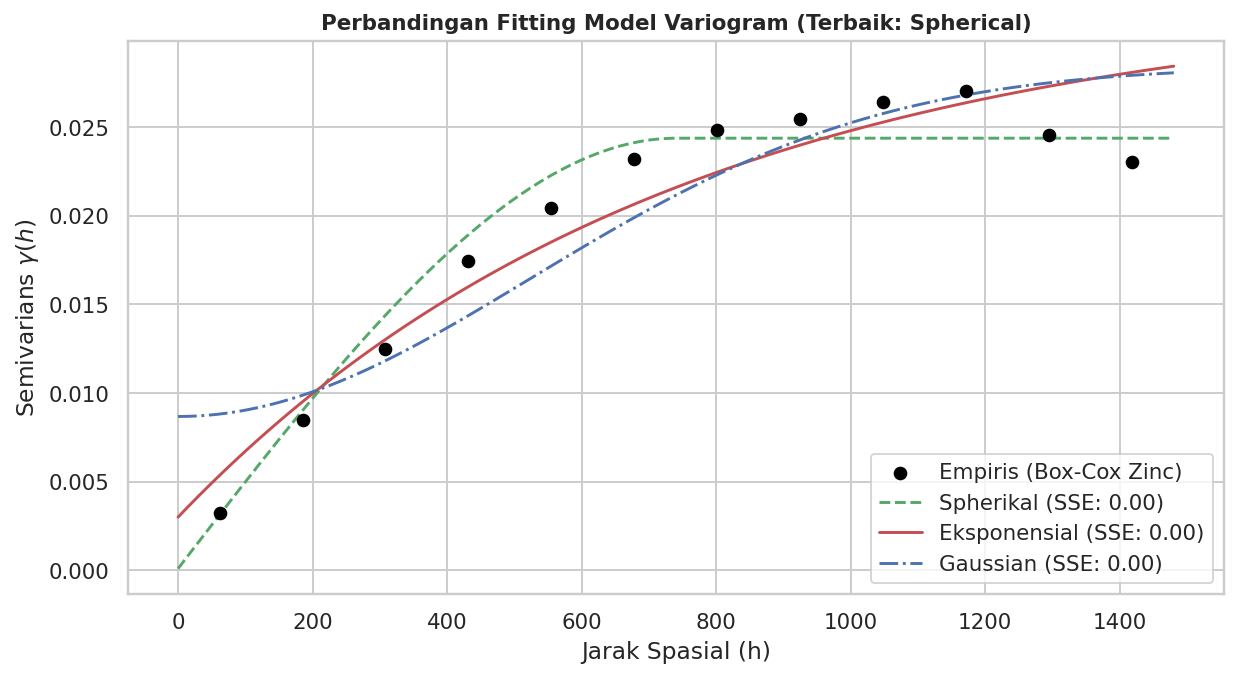

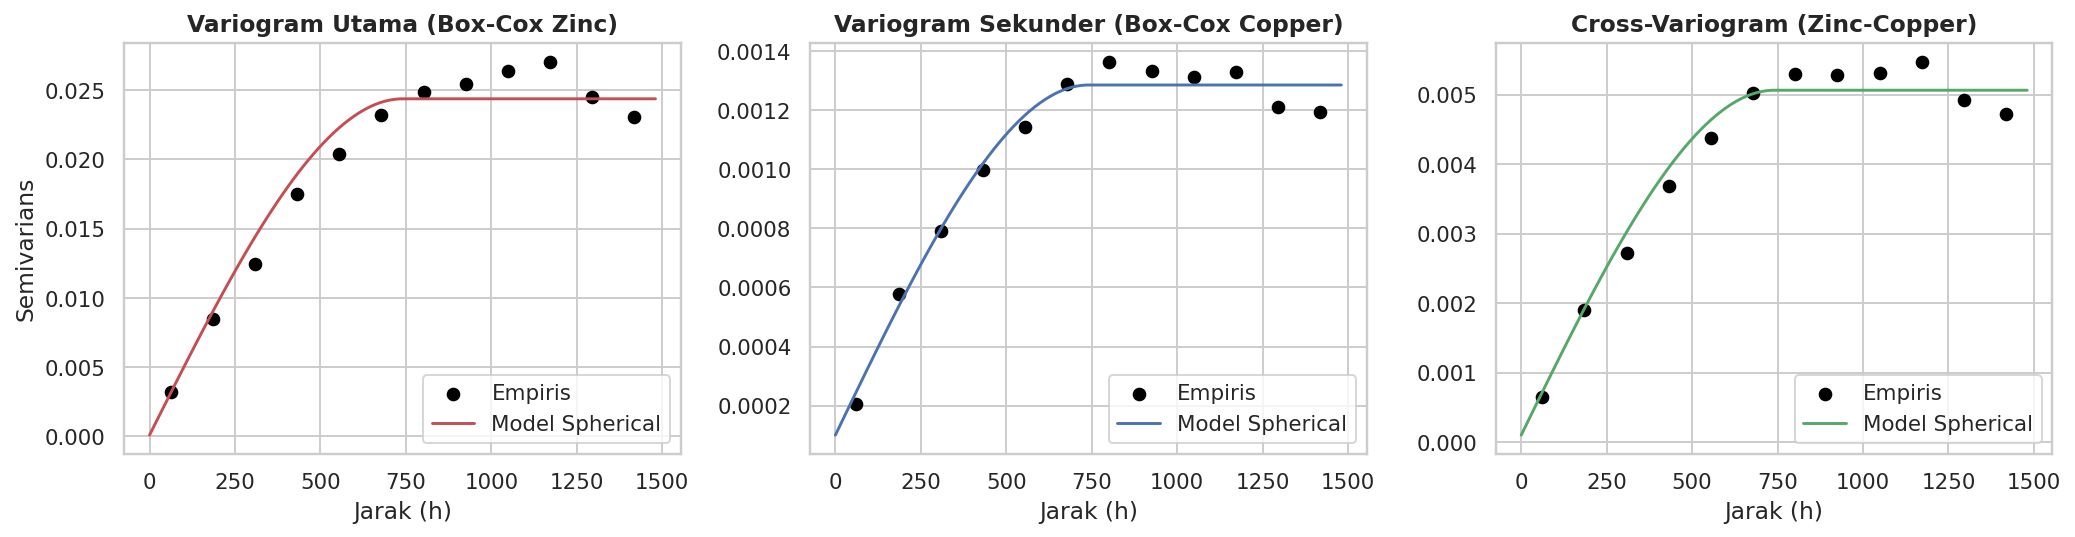


RMSE (Skala Box-Cox): 0.0761
R-Squared (R²): 0.7133


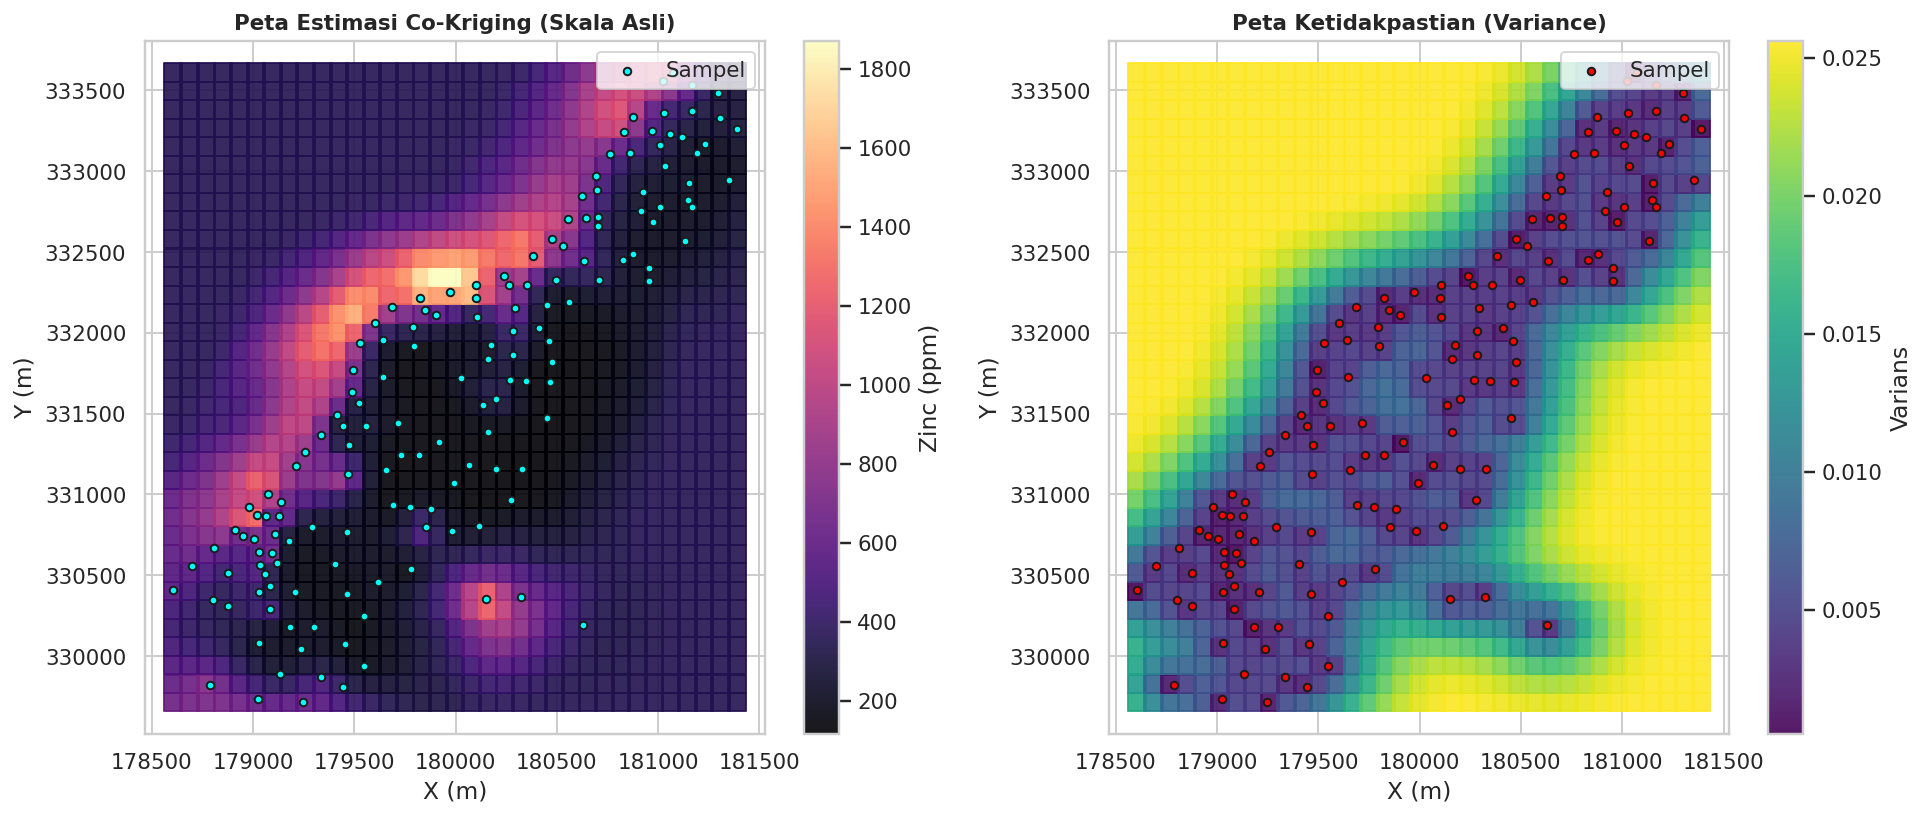

In [ ]:

#  ORDINARY CO-KRIGING ANALISIS LOGAM BERAT (ZINC & COPPER)

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
from google.colab import files
from scipy.spatial.distance import pdist, squareform
from scipy.optimize import minimize
from scipy.stats import boxcox
from sklearn.metrics import mean_squared_error, r2_score

# Pengaturan  Visualisasi
sns.set_theme(style="whitegrid")
plt.rcParams['font.family'] = 'sans-serif'
plt.rcParams['figure.dpi'] = 140

# 1. INPUT DATA DAN STATISTIK DESKRIPTIF
print("Silakan unggah file dataset (misal: meuse.csv):")
uploaded = files.upload()
filename = list(uploaded.keys())[0]
df_meuse = pd.read_csv(filename).dropna(subset=['zinc', 'copper'])

desc_table = df_meuse[['zinc', 'copper']].describe().T[['count', 'mean', 'std', 'min', '50%', 'max']]
desc_table.columns = ['Count', 'Mean', 'Std', 'Min', 'Median', 'Max']
print("\n" + "="*50)
print("STATISTIK DESKRIPTIF DATA AWAL:")
print("="*50)
print(desc_table.to_string())

# Transformasi Box-Cox untuk mendekatkan ke normalitas optimal
df_meuse['trans_zinc'], lam_zinc = boxcox(df_meuse['zinc'])
df_meuse['trans_copper'], lam_copper = boxcox(df_meuse['copper'])

print(f"\nOptimal Lambda Box-Cox Zinc   : {lam_zinc:.4f}")
print(f"Optimal Lambda Box-Cox Copper : {lam_copper:.4f}")

# Fungsi Inverse Box-Cox untuk mengembalikan nilai ke skala asli saat prediksi
def inverse_boxcox(val, lam):
    if lam == 0:
        return np.exp(val)
    else:
        return np.maximum(0, (lam * val + 1)) ** (1.0 / lam)

corr_matrix_table = df_meuse[['trans_zinc', 'trans_copper']].corr()

# 2. VISUALISASI KOMPARATIF: DATA ASLI VS TRANSFORMASI BOX-COX
fig, axes = plt.subplots(2, 2, figsize=(14, 10))

# Histogram Data Asli
sns.histplot(df_meuse['zinc'], kde=True, ax=axes[0, 0], color='orange')
axes[0, 0].set_title('Distribusi Asli - Zinc', fontsize=11, fontweight='bold')
axes[0, 0].set_xlabel('Zinc Asli (ppm)')
axes[0, 0].set_ylabel('Frekuensi')

sns.histplot(df_meuse['copper'], kde=True, ax=axes[0, 1], color='brown')
axes[0, 1].set_title('Distribusi Asli - Copper', fontsize=11, fontweight='bold')
axes[0, 1].set_xlabel('Copper Asli (ppm)')
axes[0, 1].set_ylabel('Frekuensi')

# Histogram Hasil Transformasi Box-Cox
sns.histplot(df_meuse['trans_zinc'], kde=True, ax=axes[1, 0], color='royalblue')
axes[1, 0].set_title(f'Distribusi Box-Cox - Zinc ($\lambda$ = {lam_zinc:.3f})', fontsize=11, fontweight='bold')
axes[1, 0].set_xlabel('Box-Cox Transformed Zinc')
axes[1, 0].set_ylabel('Frekuensi')

sns.histplot(df_meuse['trans_copper'], kde=True, ax=axes[1, 1], color='forestgreen')
axes[1, 1].set_title(f'Distribusi Box-Cox - Copper ($\lambda$ = {lam_copper:.3f})', fontsize=11, fontweight='bold')
axes[1, 1].set_xlabel('Box-Cox Transformed Copper')
axes[1, 1].set_ylabel('Frekuensi')

plt.tight_layout()
plt.show()

# 3. PERHITUNGAN VARIOGRAM EMPIRIS DAN CROSS-VARIOGRAM
coords = df_meuse[['x', 'y']].values
z1 = df_meuse['trans_zinc'].values
z2 = df_meuse['trans_copper'].values

def compute_variogram(coords, z_a, z_b=None, n_lags=12, max_dist=None):
    dist_matrix = squareform(pdist(coords))
    if max_dist is None:
        max_dist = np.max(dist_matrix) / 3.0
    bins = np.linspace(0, max_dist, n_lags + 1)
    lags = 0.5 * (bins[:-1] + bins[1:])
    gamma_emp = []

    for i in range(n_lags):
        mask = (dist_matrix >= bins[i]) & (dist_matrix < bins[i+1])
        if np.sum(mask) > 0:
            dz_a = z_a[:, None] - z_a[None, :]
            if z_b is None:
                g = 0.5 * np.mean((dz_a[mask])**2)
            else:
                dz_b = z_b[:, None] - z_b[None, :]
                g = 0.5 * np.mean(dz_a[mask] * dz_b[mask])
            gamma_emp.append(g)
        else:
            gamma_emp.append(np.nan)
    return lags, np.array(gamma_emp)

max_d = np.max(pdist(coords)) / 3.0
lags, g_z1 = compute_variogram(coords, z1, max_dist=max_d)
lags, g_z2 = compute_variogram(coords, z2, max_dist=max_d)
lags, g_cross = compute_variogram(coords, z1, z2, max_dist=max_d)


# 4. FITTING MODEL TEORETIS, PERBANDINGAN SSE, & VISUALISASI FITTING
def spherical_model(h, c0, c, a):
    h = np.asarray(h)
    res = np.zeros_like(h, dtype=float)
    mask = h <= a
    res[mask] = c0 + c * ((1.5 * (h[mask] / a)) - (0.5 * (h[mask] / a)**3))
    res[~mask] = c0 + c
    return res

def exponential_model(h, c0, c, a):
    h = np.asarray(h)
    return c0 + c * (1.0 - np.exp(-h / a))

def gaussian_model(h, c0, c, a):
    h = np.asarray(h)
    return c0 + c * (1.0 - np.exp(-(h**2) / (a**2)))

def fit_model_with_sse(lags, gamma_emp, model_type='exponential'):
    def loss(params):
        c0, c, a = params
        if c0 < 0 or c < 0 or a <= 0:
            return 1e9
        if model_type == 'spherical':
            pred = spherical_model(lags, c0, c, a)
        elif model_type == 'gaussian':
            pred = gaussian_model(lags, c0, c, a)
        else:
            pred = exponential_model(lags, c0, c, a)
        valid = ~np.isnan(gamma_emp)
        return np.sum((gamma_emp[valid] - pred[valid])**2)

    res = minimize(loss, [np.nanmin(gamma_emp), np.nanmax(gamma_emp)-np.nanmin(gamma_emp), max_d/2],
                   bounds=[(1e-4, None), (1e-4, None), (10, max_d*2)], method='L-BFGS-B')
    return res.x, res.fun

p_sph, sse_sph = fit_model_with_sse(lags, g_z1, model_type='spherical')
p_exp, sse_exp = fit_model_with_sse(lags, g_z1, model_type='exponential')
p_gau, sse_gau = fit_model_with_sse(lags, g_z1, model_type='gaussian')

print("\n" + "="*50)
print(" TABEL PERBANDINGAN SSE (SUM OF SQUARED ERRORS)")
print("="*50)
print(f" SSE Model Spherikal    : {sse_sph:.4f}")
print(f" SSE Model Eksponensial : {sse_exp:.4f}")
print(f" SSE Model Gaussian     : {sse_gau:.4f}")
print("="*50)

models_sse = {'spherical': sse_sph, 'exponential': sse_exp, 'gaussian': sse_gau}
best_model_name = min(models_sse, key=models_sse.get)
print(f" Model Variogram Terbaik Terpilih : {best_model_name.capitalize()}")
print("="*50)

p_11, _ = fit_model_with_sse(lags, g_z1, model_type=best_model_name)
p_22, _ = fit_model_with_sse(lags, g_z2, model_type=best_model_name)
p_12, _ = fit_model_with_sse(lags, g_cross, model_type=best_model_name)

h_plot = np.linspace(0, max_d, 100)

def evaluate_model_func(h, params, m_type):
    if m_type == 'spherical':
        return spherical_model(h, *params)
    elif m_type == 'gaussian':
        return gaussian_model(h, *params)
    else:
        return exponential_model(h, *params)

# Visualisasi 1: Perbandingan Tiga Model pada Variogram Utama
plt.figure(figsize=(9, 5))
plt.scatter(lags, g_z1, color='black', label='Empiris (Box-Cox Zinc)', zorder=5)
plt.plot(h_plot, spherical_model(h_plot, *p_sph), 'g--', label=f'Spherikal (SSE: {sse_sph:.2f})')
plt.plot(h_plot, exponential_model(h_plot, *p_exp), 'r-', label=f'Eksponensial (SSE: {sse_exp:.2f})')
plt.plot(h_plot, gaussian_model(h_plot, *p_gau), 'b-.', label=f'Gaussian (SSE: {sse_gau:.2f})')
plt.title(f'Perbandingan Fitting Model Variogram (Terbaik: {best_model_name.capitalize()})', fontsize=11, fontweight='bold')
plt.xlabel('Jarak Spasial (h)')
plt.ylabel('Semivarians $\gamma(h)$')
plt.legend(loc='lower right')
plt.tight_layout()
plt.show()

# Visualisasi 2: Panel 3 Komponen Model Terpilih (Utama, Sekunder, Cross-Variogram)
plt.figure(figsize=(15, 4))
plt.subplot(1, 3, 1)
plt.scatter(lags, g_z1, label='Empiris', color='black')
plt.plot(h_plot, evaluate_model_func(h_plot, p_11, best_model_name), 'r-', label=f'Model {best_model_name.capitalize()}')
plt.title('Variogram Utama (Box-Cox Zinc)', fontweight='bold')
plt.xlabel('Jarak (h)')
plt.ylabel('Semivarians')
plt.legend()

plt.subplot(1, 3, 2)
plt.scatter(lags, g_z2, label='Empiris', color='black')
plt.plot(h_plot, evaluate_model_func(h_plot, p_22, best_model_name), 'b-', label=f'Model {best_model_name.capitalize()}')
plt.title('Variogram Sekunder (Box-Cox Copper)', fontweight='bold')
plt.xlabel('Jarak (h)')
plt.legend()

plt.subplot(1, 3, 3)
plt.scatter(lags, g_cross, label='Empiris', color='black')
plt.plot(h_plot, evaluate_model_func(h_plot, p_12, best_model_name), 'g-', label=f'Model {best_model_name.capitalize()}')
plt.title('Cross-Variogram (Zinc-Copper)', fontweight='bold')
plt.xlabel('Jarak (h)')
plt.legend()
plt.tight_layout()
plt.show()


# 5. PEMBENTUKAN SISTEM MATRIKS ORDINARY CO-KRIGING
def co_krig_predict_single(coords, z1, z2, target_coord):
    n = len(coords)
    D = squareform(pdist(coords))

    G11 = evaluate_model_func(D, p_11, best_model_name)
    G22 = evaluate_model_func(D, p_22, best_model_name)
    G12 = evaluate_model_func(D, p_12, best_model_name)

    sz = 2 * n + 2
    K = np.zeros((sz, sz))

    K[:n, :n] = G11
    K[:n, n:2*n] = G12
    K[n:2*n, :n] = G12.T
    K[n:2*n, n:2*n] = G22

    K[:n, 2*n] = 1.0
    K[2*n, :n] = 1.0
    K[n:2*n, 2*n+1] = 1.0
    K[2*n+1, n:2*n] = 1.0

    dt = np.sqrt(np.sum((coords - target_coord)**2, axis=1))

    k0 = np.zeros(sz)
    k0[:n] = evaluate_model_func(dt, p_11, best_model_name)
    k0[n:2*n] = evaluate_model_func(dt, p_12, best_model_name)
    k0[2*n] = 1.0
    k0[2*n+1] = 0.0

    try:
        K_stable = K.copy()
        np.fill_diagonal(K_stable[:2*n, :2*n], K_stable.diagonal()[:2*n] + 1e-5)

        weights = np.linalg.solve(K_stable, k0)
        lam1 = weights[:n]
        lam2 = weights[n:2*n]
        m1 = weights[2*n]

        trans_pred = np.sum(lam1 * z1) + np.sum(lam2 * z2)
        variance = np.sum(lam1 * k0[:n]) + np.sum(lam2 * k0[n:2*n]) + m1

        orig_pred = inverse_boxcox(trans_pred, lam_zinc)
        return orig_pred, trans_pred, max(0, variance)
    except:
        mean_val = np.mean(z1)
        return inverse_boxcox(mean_val, lam_zinc), mean_val, 0.0

# 6. VALIDASI SILANG (LOOCV)
y_true_trans = z1
y_pred_trans = []

for i in range(len(coords)):
    mask = np.ones(len(coords), dtype=bool)
    mask[i] = False
    _, t_pred, _ = co_krig_predict_single(coords[mask], z1[mask], z2[mask], coords[i])
    y_pred_trans.append(t_pred)

y_pred_trans = np.array(y_pred_trans)
rmse = np.sqrt(mean_squared_error(y_true_trans, y_pred_trans))
r2 = r2_score(y_true_trans, y_pred_trans)

print(f"\nRMSE (Skala Box-Cox): {rmse:.4f}")
print(f"R-Squared (R²): {r2:.4f}")

# 7. PEMETAAN SPASIAL HASIL INTERPOLASI
grid_x = np.linspace(df_meuse['x'].min(), df_meuse['x'].max(), 35)
grid_y = np.linspace(df_meuse['y'].min(), df_meuse['y'].max(), 35)
GX, GY = np.meshgrid(grid_x, grid_y)
G_coords = np.c_[GX.ravel(), GY.ravel()]

preds_original = []
co_krig_vars = []

for pt in G_coords:
    p_orig, _, var = co_krig_predict_single(coords, z1, z2, pt)
    preds_original.append(p_orig)
    co_krig_vars.append(var)

fig, axes = plt.subplots(1, 2, figsize=(14, 6))

sc1 = axes[0].scatter(G_coords[:, 0], G_coords[:, 1], c=preds_original, cmap='magma', s=90, marker='s', alpha=0.9)
axes[0].scatter(df_meuse['x'], df_meuse['y'], c='cyan', s=15, edgecolors='k', label='Sampel')
axes[0].set_title('Peta Estimasi Co-Kriging (Skala Asli)', fontsize=11, fontweight='bold')
axes[0].set_xlabel('X (m)')
axes[0].set_ylabel('Y (m)')
axes[0].legend(loc='upper right')
fig.colorbar(sc1, ax=axes[0], label='Zinc (ppm)')

sc2 = axes[1].scatter(G_coords[:, 0], G_coords[:, 1], c=co_krig_vars, cmap='viridis', s=90, marker='s', alpha=0.9)
axes[1].scatter(df_meuse['x'], df_meuse['y'], c='red', s=15, edgecolors='k', label='Sampel')
axes[1].set_title('Peta Ketidakpastian (Variance)', fontsize=11, fontweight='bold')
axes[1].set_xlabel('X (m)')
axes[1].set_ylabel('Y (m)')
axes[1].legend(loc='upper right')
fig.colorbar(sc2, ax=axes[1], label='Varians')

plt.tight_layout()
plt.show()